# Model EDA: Feature Analysis & Selection

This notebook provides tools for:
1. Loading merged training data (D1+D2)
2. Correlation analysis
3. Feature importance (XGBoost)
4. SHAP explainability
5. Outputting a selected feature list for `src/feature_config.py`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import xgboost as xgb
import sys
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

# Add project root to path
sys.path.append(str(Path.cwd().parent))

from src.feature_config import get_model_features, TECHNICAL_FEATURES, ALPHA_FEATURES

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

## 1. Load Training Data

In [2]:
# Load the merged dataset (output from model_trainer.py Step 2)
data_path = Path('../data/ml/d2_features.parquet')

if data_path.exists():
    df = pd.read_parquet(data_path)
    print(f"Loaded {len(df)} samples with {len(df.columns)} columns")
    print(f"Date range: {df['date'].min()} to {df['date'].max()}")
    print(f"Label distribution: {df['label'].value_counts().to_dict()}")
    print(df.info())
else:
    print(f"❌ Data not found at {data_path}")
    print("   Run: python model_trainer.py --start 2018-01-01 --end 2023-12-31")

df_orig = df.copy()
# Preview data
df.head(1)
# Print a readable sample of the first 5 rows
print(df.head(5).to_markdown(index=False, numalign="left", stralign="left"))

Loaded 14448 samples with 128 columns
Date range: 2018-04-03 00:00:00 to 2025-12-31 00:00:00
Label distribution: {0: 12960, 1: 1488}
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14448 entries, 0 to 14447
Columns: 128 entries, date to is_declining_earnings
dtypes: bool(3), datetime64[ns](3), float64(113), int64(6), object(3)
memory usage: 13.8+ MB
None
| date                | ticker   | label   | return_pct   | days_held   | exit_reason   | Open   | High   | Low   | Close   | Volume   | SMA_50   | Price_vs_SMA_50   | SMA_150   | Price_vs_SMA_150   | SMA_200   | Price_vs_SMA_200   | ATR      | High_52W   | Low_52W   | Vol_MA      | Vol_Ratio   | High_20D   | Breakout   | RS        | RS_MA     | nATR    | VCP_Ratio   | Consolidation_Width   | Dry_Up_Volume   | RSI_14   | RSI_Regime   | Dist_From_52W_High   | Is_Green_Day   | Green_Days_Ratio_20D   | SMA_50_Slope   | Lowest_Low_20D   | Dist_From_20D_Low   | Highest_High_20D   | Dist_From_20D_High   | Dist_From_52W_Low   | nATR_Lag1   

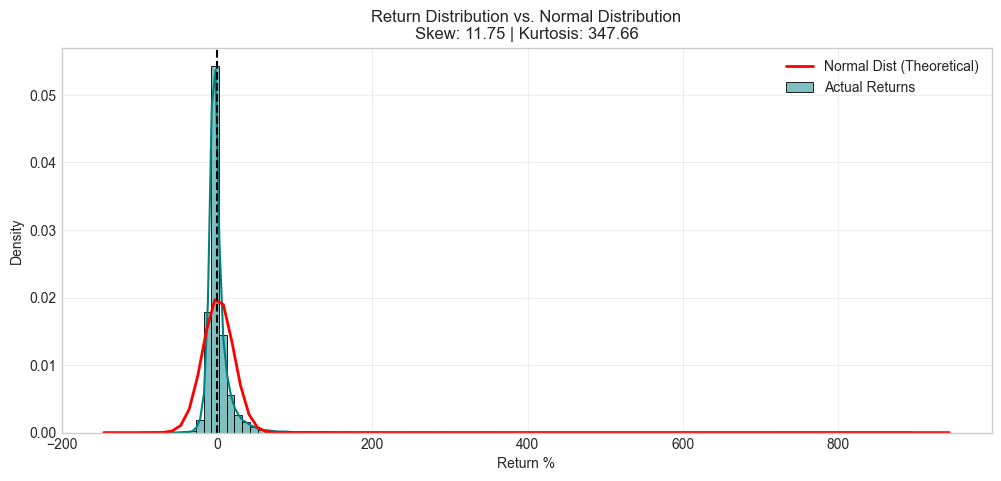

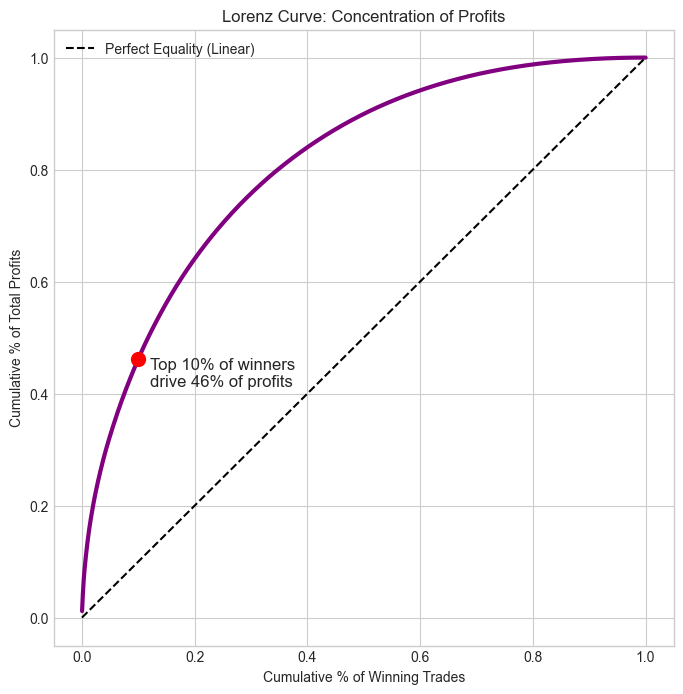

------------------------------
DISTRIBUTION STATISTICS
------------------------------
Total Trades:       14448
Win Rate:           35.40%
Avg Win:            +15.05%
Avg Loss:           -6.06%
Risk/Reward Ratio:  2.48x
Expectancy:         1.41% per trade
------------------------------
Trades > +10%:      14.72% (The 'Fat Tail')
Skewness:           11.75 (Positive = Good for Longs)
------------------------------


In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df_mod = df_orig.copy()
# Assume df_mod is your final dataframe with 'return_pct'
returns = df_mod['return_pct'].dropna()

# --- 1. THE SHAPE VISUALIZATION (Histogram) ---
plt.figure(figsize=(12, 5))

# Plot Histogram with KDE
sns.histplot(returns, bins=100, kde=True, color='teal', stat="density", label='Actual Returns')

# Overlay a Normal Distribution for comparison (to show how "fat" your tails are)
mu, std = stats.norm.fit(returns)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'r', linewidth=2, label='Normal Dist (Theoretical)')

plt.title(f"Return Distribution vs. Normal Distribution\nSkew: {returns.skew():.2f} | Kurtosis: {returns.kurtosis():.2f}")
plt.xlabel("Return %")
plt.legend()
plt.axvline(0, color='black', linestyle='--') # Breakeven line
plt.grid(alpha=0.3)
plt.show()

# --- 2. THE "PARETO" CHECK (Lorenz Curve) ---
# Do 10% of trades produce 90% of gains?
sorted_returns = returns.sort_values(ascending=False)
positive_returns = sorted_returns[sorted_returns > 0]
total_positive_gain = positive_returns.sum()

# Calculate Cumulative Gain %
cumulative_gain = positive_returns.cumsum() / total_positive_gain
trade_count_pct = np.arange(1, len(positive_returns) + 1) / len(positive_returns)

plt.figure(figsize=(8, 8))
plt.plot(trade_count_pct, cumulative_gain, linewidth=3, color='purple')
plt.plot([0, 1], [0, 1], 'k--', label="Perfect Equality (Linear)")
plt.title("Lorenz Curve: Concentration of Profits")
plt.xlabel("Cumulative % of Winning Trades")
plt.ylabel("Cumulative % of Total Profits")
plt.grid(True)

# Annotate the "Top 10%" point
top_10_gain = cumulative_gain.iloc[int(len(positive_returns) * 0.1)]
plt.scatter(0.1, top_10_gain, color='red', s=100, zorder=5)
plt.text(0.12, top_10_gain - 0.05, f"Top 10% of winners\ndrive {top_10_gain:.0%} of profits", fontsize=12)
plt.legend()
plt.show()

# --- 3. KEY STATISTICS REPORT ---
win_rate = (returns > 0).mean() * 100
avg_win = returns[returns > 0].mean()
avg_loss = returns[returns <= 0].mean()
risk_reward = abs(avg_win / avg_loss)
big_winners = (returns > 10).mean() * 100

print("-" * 30)
print("DISTRIBUTION STATISTICS")
print("-" * 30)
print(f"Total Trades:       {len(returns)}")
print(f"Win Rate:           {win_rate:.2f}%")
print(f"Avg Win:            +{avg_win:.2f}%")
print(f"Avg Loss:           {avg_loss:.2f}%")
print(f"Risk/Reward Ratio:  {risk_reward:.2f}x")
print(f"Expectancy:         {(win_rate/100 * avg_win) + ((1-win_rate/100) * avg_loss):.2f}% per trade")
print("-" * 30)
print(f"Trades > +10%:      {big_winners:.2f}% (The 'Fat Tail')")
print(f"Skewness:           {returns.skew():.2f} (Positive = Good for Longs)")
print("-" * 30)

Calculating daily portfolio load (this may take a moment)...
------------------------------
REALITY CHECK STATISTICS
------------------------------
Max Concurrent Trades:    810 stocks needed
Average Concurrent:       218.4 stocks
Days with >10 Signals:    2811 days (98.8% of time)
------------------------------
⚠️ CRITICAL: To achieve the $5T result, you used 8100% Leverage.
   In reality, you would have missed the other trades.


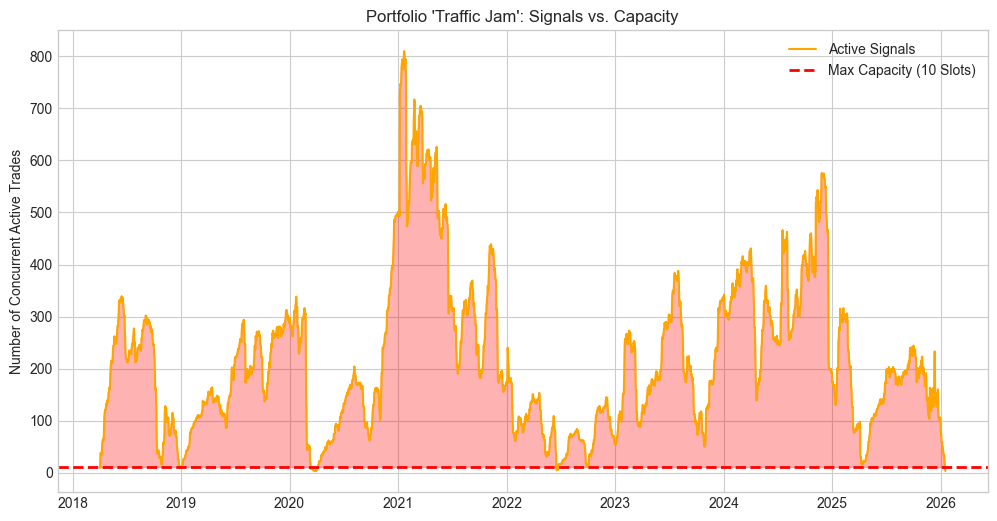

In [70]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. SETUP DATES
df_mod['date'] = pd.to_datetime(df_mod['date'])
df_mod['exit_date'] = df_mod['date'] + pd.to_timedelta(df_mod['days_held'], unit='D')

# 2. CALCULATE CONCURRENT TRADES
# We create a timeline of every single day in the backtest
all_dates = pd.date_range(start=df_mod['date'].min(), end=df_mod['exit_date'].max())
daily_positions = pd.Series(0, index=all_dates)

print("Calculating daily portfolio load (this may take a moment)...")

# Brute force method (reliable): For every trade, add +1 to all days it was held
for _, row in df_mod.iterrows():
    # Clip exit date to max of dataset to avoid errors
    start = row['date']
    end = row['exit_date']
    daily_positions[start:end] += 1

# 3. ANALYZE THE "IMPOSSIBLE" DAYS
max_positions = daily_positions.max()
avg_positions = daily_positions.mean()
overload_days = (daily_positions > 10).sum()
pct_overload = (overload_days / len(daily_positions)) * 100

print("-" * 30)
print("REALITY CHECK STATISTICS")
print("-" * 30)
print(f"Max Concurrent Trades:    {max_positions} stocks needed")
print(f"Average Concurrent:       {avg_positions:.1f} stocks")
print(f"Days with >10 Signals:    {overload_days} days ({pct_overload:.1f}% of time)")
print("-" * 30)

if max_positions > 10:
    required_leverage = (max_positions * 10) # if 10% per trade
    print(f"⚠️ CRITICAL: To achieve the $5T result, you used {required_leverage}% Leverage.")
    print("   In reality, you would have missed the other trades.")

# 4. PLOT THE BOTTLENECK
plt.figure(figsize=(12, 6))
plt.plot(daily_positions.index, daily_positions.values, color='orange', label='Active Signals')
plt.axhline(10, color='red', linestyle='--', linewidth=2, label='Max Capacity (10 Slots)')
plt.title("Portfolio 'Traffic Jam': Signals vs. Capacity")
plt.ylabel("Number of Concurrent Active Trades")
plt.legend()
plt.fill_between(daily_positions.index, 10, daily_positions.values, where=(daily_positions > 10), color='red', alpha=0.3)
plt.show()


--- PERFORMANCE BY HOLDING PERIOD ---
                         mean     median  count           sum    Win_Rate
Duration_Bucket                                                          
Scalp (<1 wk)       -3.574228  -2.527342   2048  -7320.018287   19.921875
Swing (1-2 wks)     -6.631779  -5.976742   1352  -8966.164544    7.100592
Position (2-4 wks)  -7.043956  -6.499020   2067 -14559.856762    4.789550
Trend (1-2 mos)     -2.875383  -3.573521   5249 -15092.884777   19.641837
Campaign (2-6 mos)  12.390545   8.081958   3023  37456.618053   91.663910
Long Term (6mo+)    40.709038  29.278568    709  28862.708190  100.000000


C:\Users\Hang\AppData\Local\Temp\ipykernel_48632\2132937039.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  duration_stats = df_analysis.groupby('Duration_Bucket')['return_pct'].agg(['mean', 'median', 'count', 'sum'])
C:\Users\Hang\AppData\Local\Temp\ipykernel_48632\2132937039.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  duration_stats['Win_Rate'] = df_analysis.groupby('Duration_Bucket')['return_pct'].apply(lambda x: (x > 0).mean() * 100)
C:\Users\Hang\AppData\Local\Temp\ipykernel_48632\2132937039.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed 

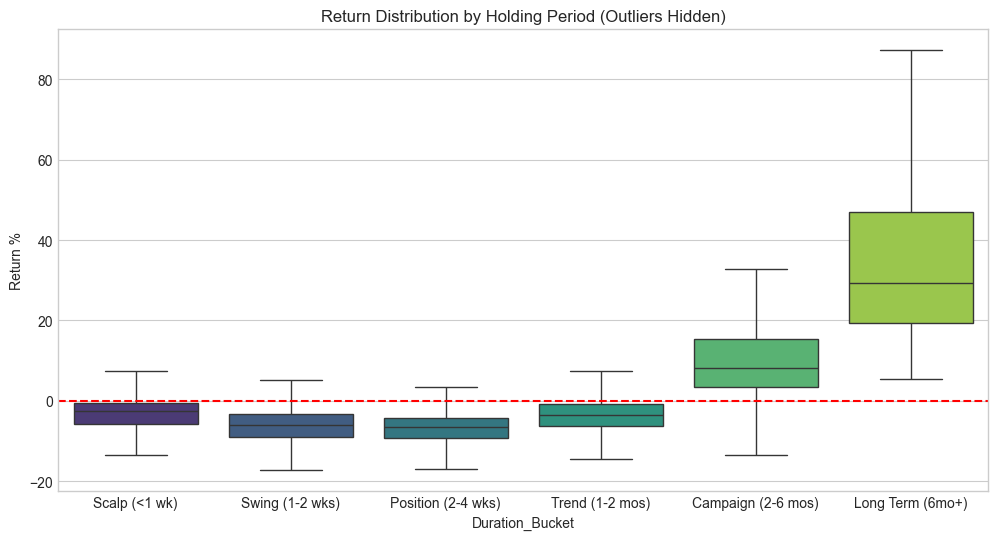

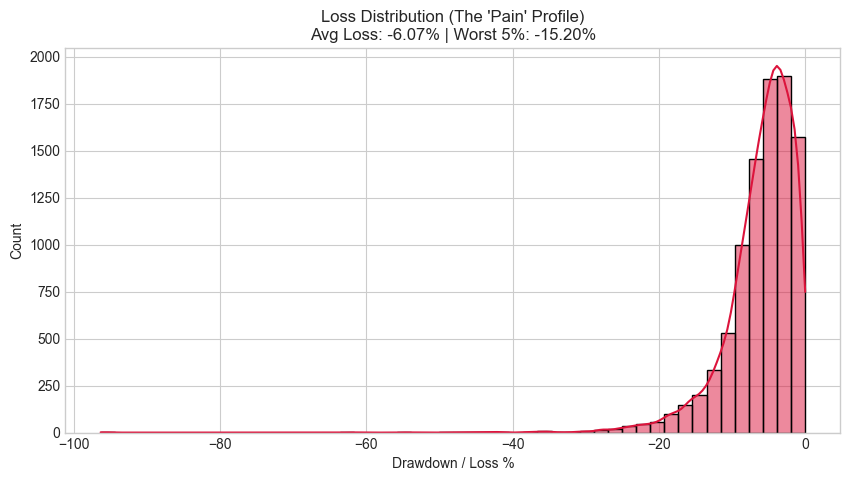


Correlation (Days Held vs Return): 0.5890
------------------------------
TIME MANAGEMENT STATS
------------------------------
Avg Holding Period (Winners): 76.8 days
Avg Holding Period (Losers):  22.9 days
Time Skew Ratio:              3.35x
(Goal: Winners should be held 2x-3x longer than losers)
------------------------------


In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. PREPARE DATA ---
# Ensure we work with valid completed trades only
df_analysis = df_mod[df_mod['days_held'] > 0].copy()

# --- 2. HOLDING PERIOD ANALYSIS ---
# Bucketize the holding periods to find the "Sweet Spot"
bins = [0, 5, 10, 20, 60, 120, 500]
labels = ['Scalp (<1 wk)', 'Swing (1-2 wks)', 'Position (2-4 wks)', 'Trend (1-2 mos)', 'Campaign (2-6 mos)', 'Long Term (6mo+)']
df_analysis['Duration_Bucket'] = pd.cut(df_analysis['days_held'], bins=bins, labels=labels)

# Group performance by bucket
duration_stats = df_analysis.groupby('Duration_Bucket')['return_pct'].agg(['mean', 'median', 'count', 'sum'])
duration_stats['Win_Rate'] = df_analysis.groupby('Duration_Bucket')['return_pct'].apply(lambda x: (x > 0).mean() * 100)

print("\n--- PERFORMANCE BY HOLDING PERIOD ---")
print(duration_stats)

# Plot: Return vs Duration
plt.figure(figsize=(12, 6))
sns.boxplot(x='Duration_Bucket', y='return_pct', data=df_analysis, showfliers=False, palette='viridis')
plt.title('Return Distribution by Holding Period (Outliers Hidden)')
plt.axhline(0, color='red', linestyle='--')
plt.ylabel('Return %')
plt.show()

# --- 3. TRADE DRAWDOWN DISTRIBUTION ---
# Since we don't have intraday data for every trade in the CSV, we approximate Max Drawdown 
# using the 'Low' relative to 'Open' (or Entry Price).
# Formula Estimate: (Lowest Low during trade - Entry) / Entry
# Note: In your specific DF, you only have 'Low' for the entry day or current row. 
# We will assume 'Low' column represents the lowest price during the holding period if it's a summary row, 
# otherwise we can only infer from return. 
# *CRITICAL UPDATE*: If this is a summary row per trade, we need 'Lowest_Low_During_Trade'. 
# Lacking that, we analyze the distribution of *Losing Trades* to see the "Pain Profile".

losses = df_analysis[df_analysis['return_pct'] < 0]['return_pct']

plt.figure(figsize=(10, 5))
sns.histplot(losses, bins=50, color='crimson', kde=True)
plt.title(f"Loss Distribution (The 'Pain' Profile)\nAvg Loss: {losses.mean():.2f}% | Worst 5%: {losses.quantile(0.05):.2f}%")
plt.xlabel("Drawdown / Loss %")
plt.show()

# --- 4. FINDING THE "BEST" PERIOD ---
# Correlation check
corr_days = df_analysis['days_held'].corr(df_analysis['return_pct'])
print(f"\nCorrelation (Days Held vs Return): {corr_days:.4f}")

# The "Golden Rule" Check: Average Days Held for Winners vs Losers
avg_hold_win = df_analysis[df_analysis['return_pct'] > 0]['days_held'].mean()
avg_hold_loss = df_analysis[df_analysis['return_pct'] <= 0]['days_held'].mean()

print("-" * 30)
print("TIME MANAGEMENT STATS")
print("-" * 30)
print(f"Avg Holding Period (Winners): {avg_hold_win:.1f} days")
print(f"Avg Holding Period (Losers):  {avg_hold_loss:.1f} days")
print(f"Time Skew Ratio:              {avg_hold_win / avg_hold_loss:.2f}x")
print("(Goal: Winners should be held 2x-3x longer than losers)")
print("-" * 30)

## 2. Feature Filtering

In [60]:
FEATURES_TO_LAG = [
    'nATR', 'ATR', 'VCP_Ratio', 'Consolidation_Width',
    'Price_vs_SMA_50', 'Price_vs_SMA_150', 'Price_vs_SMA_200',
    'RS', 'RS_MA', 'Dry_Up_Volume',
    'High_52W', 'Low_52W', 'Lowest_Low_20D', 'Highest_High_20D',
    'RSI_14', 'Dist_From_52W_High', 'Dist_From_52W_Low', 'Dist_From_20D_Low', 'Dist_From_20D_High'
]

lag_features = [f"{f}_Lag1" for f in FEATURES_TO_LAG]
delta_features = [f"{feature}_Delta" for feature in FEATURES_TO_LAG]

# Get numeric features only
exclude_cols = ['date', 'ticker', 'label', 'return_pct', 'days_held', 'exit_reason', 'year']
raw_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'High_52W', 'Low_52W', 'ATR', 'Vol_MA', 'High_20D', 'ATR_Lag1', 
            'High_52W_Lag1', 'Low_52W_Lag1', 'is_stale', 'has_fundamentals', 'SMA_50', 'SMA_150', 'SMA_200', 'RS_MA']
delta_cols_drop = [
    # contraction
    'ATR_Delta', 'VCP_Ratio_Delta', 'Dist_From_52W_Low_Delta', 'Dist_From_20D_Low_Delta',
    # momentum
    'Highest_High_20D_Delta', 'High_52W_Delta', 'RS_MA_Delta',
    'nATR_Delta'
] 

price_structure = [
    'High_52W',
    'Low_52W',
    'Lowest_Low_20D',        # 20-day low value (needed for distance calc)
    'Highest_High_20D',      # 20-day high value (needed for distance calc)
    'High_20D',              # 20-day high (for breakout detection)
    'Lowest_Low_20D_Lag1',   # Lagged 20-day low value
    'Highest_High_20D_Lag1', # Lagged 20-day
]

# drop high corr cols
high_corr_cols = ['days_since_earnings', 'Price_vs_SMA_150', 'quick_ratio', 'RS_MA', 'net_margin', 'Consolidation_Width', 'gross_margin', 'gross_margin_trend', 'net_income_growth_yoy']
fundamental_cols = ['operatingCashFlow', 'freeCashFlow', 'netIncome', 'revenue']
low_importance = ['RSI_Regime', 'RSI_14']

exclude_cols = exclude_cols + raw_cols + price_structure + high_corr_cols + delta_cols_drop + lag_features + fundamental_cols + low_importance
feature_cols = [c for c in df.columns if c not in exclude_cols and pd.api.types.is_numeric_dtype(df[c])]

print(f"Total numeric features: {len(feature_cols)}")
print(f"\nAll cols: {feature_cols[:]}")

Total numeric features: 60

All cols: ['Price_vs_SMA_50', 'Price_vs_SMA_200', 'Vol_Ratio', 'Breakout', 'RS', 'nATR', 'VCP_Ratio', 'Dry_Up_Volume', 'Dist_From_52W_High', 'Is_Green_Day', 'Green_Days_Ratio_20D', 'SMA_50_Slope', 'Dist_From_20D_Low', 'Dist_From_20D_High', 'Dist_From_52W_Low', 'Consolidation_Width_Delta', 'Price_vs_SMA_50_Delta', 'Price_vs_SMA_150_Delta', 'Price_vs_SMA_200_Delta', 'RS_Delta', 'Dry_Up_Volume_Delta', 'Low_52W_Delta', 'Lowest_Low_20D_Delta', 'RSI_14_Delta', 'Dist_From_52W_High_Delta', 'Dist_From_20D_High_Delta', 'alpha001', 'alpha006', 'alpha009', 'alpha012', 'alpha041', 'alpha101', 'alpha002', 'alpha004', 'alpha011', 'alpha013', 'alpha015', 'alpha054', 'alpha060', 'revenue_growth_yoy', 'eps_growth_yoy', 'eps_accel', 'revenue_accel', 'revenue_cagr_3y', 'eps_stability_score', 'debt_to_equity', 'current_ratio', 'operating_margin', 'roe', 'roa', 'inventory_growth_yoy', 'inventory_vs_sales_spread', 'earnings_quality_score', 'fcf_margin', 'days_since_report', 'pe_ra

In [62]:
# Check missing values
missing = df[feature_cols].isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

high_missing = missing_pct[missing_pct > 50]
if len(high_missing) > 0:
    print(f"⚠️ Features with >50% missing values ({len(high_missing)}):")
    print(high_missing)
else:
    print("✅ No features with >50% missing values")

⚠️ Features with >50% missing values (2):
inventory_vs_sales_spread    55.8
inventory_growth_yoy         54.7
dtype: float64


## 3. Correlation Analysis

In [63]:
# Compute correlation matrix
corr_matrix = df[feature_cols].corr()

# Find highly correlated pairs (|r| > 0.9)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append({
                'feature_1': corr_matrix.columns[i],
                'feature_2': corr_matrix.columns[j],
                'correlation': corr_matrix.iloc[i, j]
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('correlation', ascending=False)
print(f"Highly correlated pairs (|r| > 0.9): {len(high_corr_df)}")
high_corr_df.head(10)
# for feeding into LLM
print(high_corr_df.head(100).to_markdown(index=False, numalign="left", stralign="left"))

Highly correlated pairs (|r| > 0.9): 1
| feature_1      | feature_2             | correlation   |
|:---------------|:----------------------|:--------------|
| eps_growth_yoy | is_declining_earnings | -0.976965     |



--- Top 10 Features Correlated with Return (Spearman) ---
return_pct                  1.000000
alpha011                    0.076195
alpha060                    0.066391
operating_margin            0.061021
alpha013                    0.058355
pe_ratio                    0.053708
peg_adjusted                0.045557
debt_to_equity              0.037823
fcf_margin                  0.033118
eps_growth_yoy              0.032488
roa                         0.031096
earnings_quality_score      0.030305
RS                          0.030020
net_income_growth_yoy       0.029616
Dist_From_52W_High          0.028812
alpha012                    0.027718
Dist_From_20D_High          0.026666
roe                         0.025365
alpha009                    0.018297
Dist_From_20D_High_Delta    0.018253
alpha006                    0.017689
Lowest_Low_20D_Delta        0.016439
revenue_accel               0.015132
alpha002                    0.014434
alpha015                    0.013088
ps_ratio        

<Figure size 1000x1200 with 0 Axes>

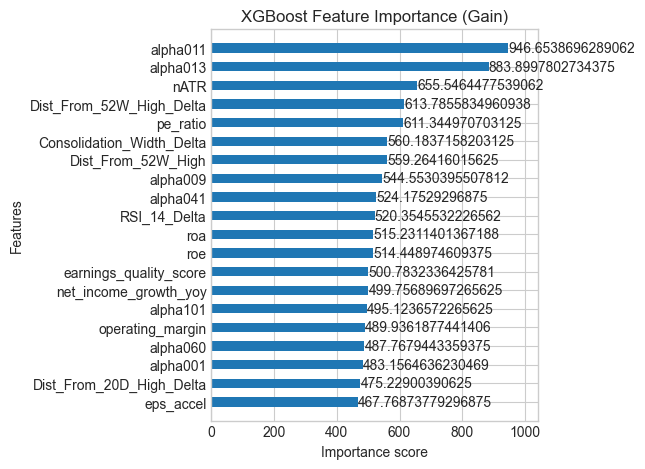

In [54]:
# target correlation and delta engineering
df = df[feature_cols+['return_pct', 'date']].copy()

# --- FINAL DATA CLEANING (The Fix for XGBoost) ---
# Replace any remaining infinite values in the entire dataframe
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# OPTIONAL: Clip extreme percentage changes to reasonable limits (e.g., +/- 1000%)
# This prevents a 50,000% change from blowing up the model gradients
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].clip(lower=-10, upper=10)

# --- 3. TARGET CORRELATION (Spearman) ---
# Use only numeric columns to avoid string errors
numeric_df = df.select_dtypes(include=[np.number])
target_corr = numeric_df.corrwith(df['return_pct'], method='spearman').sort_values(ascending=False)

print("\n--- Top 10 Features Correlated with Return (Spearman) ---")
print(target_corr.head(30))

print("\n--- Bottom 10 Features (Inverse Correlation) ---")
print(target_corr.tail(30))

# --- 4. XGBOOST FEATURE IMPORTANCE ---
# Define X and y
X = df[feature_cols]
X = X.select_dtypes(include=[np.number]) # Safety filter
y = df['return_pct']

# Train Model
model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, max_depth=4, learning_rate=0.05, n_jobs=-1)
model.fit(X, y)

# Plot
plt.figure(figsize=(10, 12))
xgb.plot_importance(model, max_num_features=20, importance_type='gain', height=0.5, title='XGBoost Feature Importance (Gain)')
plt.tight_layout()
plt.show()

In [41]:
X = df[feature_cols].copy()
# y = df['return_pct'].copy()

# --- SANITY CHECK ---
# Look for raw prices (Values > 500 usually indicate unscaled prices, except for P/E)
stats = X.describe().T
potential_raw_prices = stats[stats['max'] > 500]
print("⚠️ Potential Non-Stationary Columns (Check these!):")
print(potential_raw_prices[['min', 'max', 'mean']])

⚠️ Potential Non-Stationary Columns (Check these!):
Empty DataFrame
Columns: [min, max, mean]
Index: []


## 4. Feature Importance (XGBoost)

[I 2026-01-18 21:38:15,381] A new study created in memory with name: no-name-cf403096-a575-4ab7-b390-0c5a28011c48


Starting Tuning on 13312 trades from 2018-04-03 00:00:00 to 2025-12-31 00:00:00


[I 2026-01-18 21:38:16,212] Trial 0 finished with value: 6.742329795392321 and parameters: {'n_estimators': 184, 'max_depth': 6, 'learning_rate': 0.08102468024512552, 'subsample': 0.7969003623569393, 'colsample_bytree': 0.6406375677409532, 'reg_alpha': 8.981066971165676, 'reg_lambda': 3.061158615374185}. Best is trial 0 with value: 6.742329795392321.
[I 2026-01-18 21:38:16,756] Trial 1 finished with value: 6.582518128099719 and parameters: {'n_estimators': 108, 'max_depth': 6, 'learning_rate': 0.04767227834918587, 'subsample': 0.8137853547642562, 'colsample_bytree': 0.8036223268476623, 'reg_alpha': 5.537104699532216, 'reg_lambda': 4.351082347911603}. Best is trial 1 with value: 6.582518128099719.
[I 2026-01-18 21:38:19,591] Trial 2 finished with value: 6.708909977688838 and parameters: {'n_estimators': 454, 'max_depth': 7, 'learning_rate': 0.03290269556959184, 'subsample': 0.6858762254980474, 'colsample_bytree': 0.7764136095715126, 'reg_alpha': 9.856734325453253, 'reg_lambda': 1.924170


--- Best Parameters Found ---
{'n_estimators': 101, 'max_depth': 4, 'learning_rate': 0.01671697802303713, 'subsample': 0.7193171330474983, 'colsample_bytree': 0.8759524853423841, 'reg_alpha': 4.536128121772695, 'reg_lambda': 4.020547931085102}

Training Final Model...


<Figure size 1200x1000 with 0 Axes>

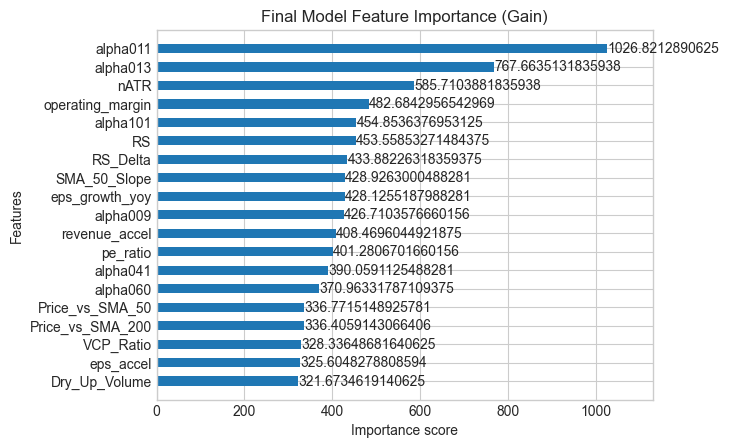

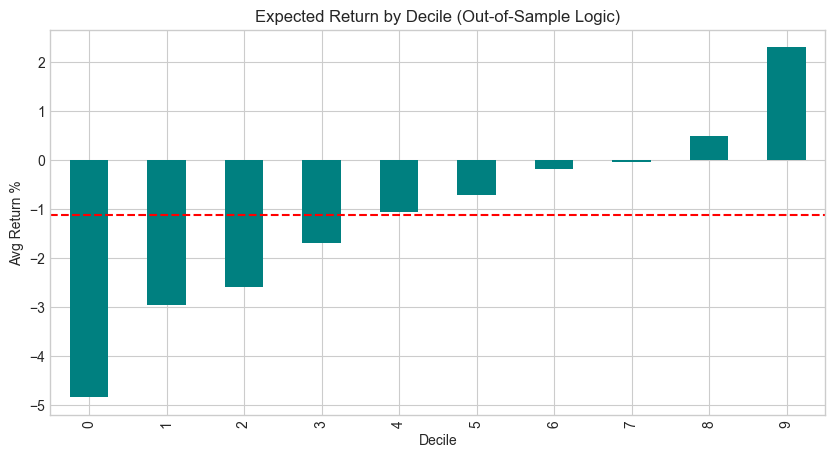

Selection Edge (Top Decile - Avg): 3.42%


In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

# --- 1. DATA PREP ---
# Define your final clean feature list (ensure leakage/broken cols are gone)
features = [
    'alpha011', 'alpha013', 'alpha041', 'alpha009', 'alpha101', 'alpha060', # Alphas
    'RS', 'RS_Delta', 'SMA_50_Slope', 'Price_vs_SMA_50', 'Price_vs_SMA_200', # Momentum/Trend
    'nATR', 'VCP_Ratio', 'Dry_Up_Volume', # Volatility/Setup
    'eps_growth_yoy', 'revenue_accel', 'operating_margin', 'pe_ratio', 'eps_accel' # Fundamentals
]
target = 'return_pct'

# Filter for valid data
df_clean_final = df.copy()
df_mod = df_clean_final.dropna(subset=features + [target]).copy()
df_mod = df_mod.sort_values('date') # CRITICAL: Sort by date for Time Series Split

X = df_mod[features]
y = df_mod[target]

print(f"Starting Tuning on {len(X)} trades from {df_mod['date'].min()} to {df_mod['date'].max()}")

# --- 2. OPTUNA OBJECTIVE FUNCTION ---
def objective(trial):
    # Define the search space
    param = {
        'objective': 'reg:squarederror',
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10), # L1 Regularization (noise filter)
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 10), # L2 Regularization
        'n_jobs': -1,
        'random_state': 42,
        'verbosity': 0
    }

    # Time Series Cross-Validation (5 Splits)
    # This simulates "Walk-Forward" testing
    tscv = TimeSeriesSplit(n_splits=5)
    scores = []

    for train_idx, val_idx in tscv.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = xgb.XGBRegressor(**param)
        model.fit(X_train, y_train, verbose=False)
        
        preds = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        scores.append(rmse)

    return np.mean(scores) # We want to minimize RMSE

# --- 3. RUN OPTIMIZATION ---
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50) # 20 trials is enough for a quick check

print("\n--- Best Parameters Found ---")
best_params = study.best_trial.params
print(best_params)

# --- 4. TRAIN FINAL MODEL & SHOW IMPORTANCE ---
print("\nTraining Final Model...")
final_model = xgb.XGBRegressor(**best_params, n_jobs=-1, random_state=42)
final_model.fit(X, y)

<Figure size 1200x1000 with 0 Axes>

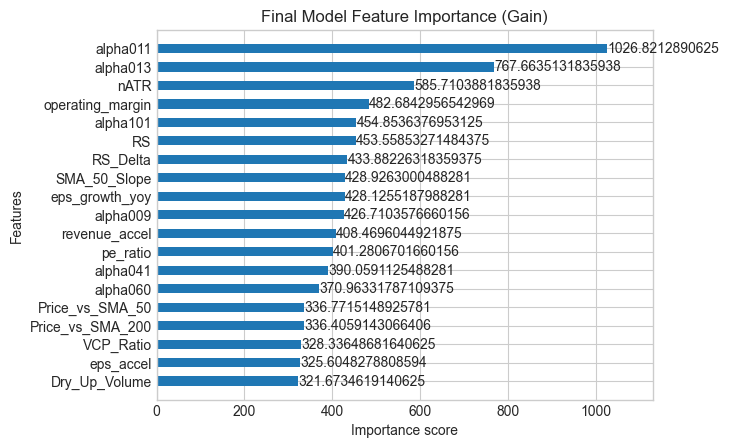

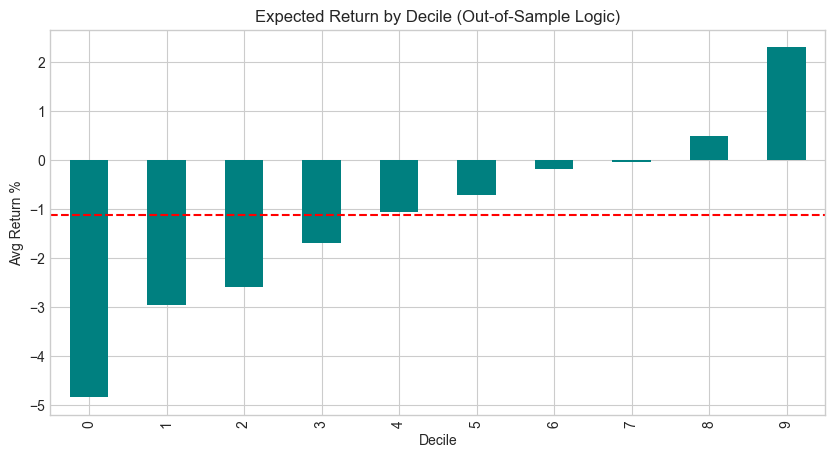

Selection Edge (Top Decile - Avg): 3.42%


In [65]:
# Plot Importance
plt.figure(figsize=(12, 10))
xgb.plot_importance(final_model, max_num_features=30, importance_type='gain', height=0.5, title='Final Model Feature Importance (Gain)')
plt.show()

# --- 5. DECILE ANALYSIS (The Real Test) ---
df_mod['Prediction'] = final_model.predict(X)
df_mod['Decile'] = pd.qcut(df_mod['Prediction'], 10, labels=False)
edge = df_mod.groupby('Decile')[target].mean()

plt.figure(figsize=(10, 5))
edge.plot(kind='bar', color='teal')
plt.title("Expected Return by Decile (Out-of-Sample Logic)")
plt.ylabel("Avg Return %")
plt.axhline(df_mod[target].mean(), color='red', linestyle='--')
plt.show()

print(f"Selection Edge (Top Decile - Avg): {edge.iloc[-1] - df_mod[target].mean():.2f}%")

In [66]:
# 1. Get the importance dictionary from the booster (matches importance_type='gain')
importance_dict = final_model.get_booster().get_score(importance_type='gain')

# 2. Sort the dictionary by value (Score) in descending order
# This mimics exactly how the plot orders the bars (longest bar first)
sorted_importances = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)

# 3. Extract just the feature names (Keys) into a list
# We slice [:30] to match your max_num_features=30 parameter
top_features_list = [k for k, v in sorted_importances[:30]]

print("--- Top Features by Gain (Ordered) ---")
print(top_features_list)

# Optional: If you want it as a simple numpy array
import numpy as np
top_features_array = np.array(top_features_list)

--- Top Features by Gain (Ordered) ---
['alpha011', 'alpha013', 'nATR', 'operating_margin', 'alpha101', 'RS', 'RS_Delta', 'SMA_50_Slope', 'eps_growth_yoy', 'alpha009', 'revenue_accel', 'pe_ratio', 'alpha041', 'alpha060', 'Price_vs_SMA_50', 'Price_vs_SMA_200', 'VCP_Ratio', 'eps_accel', 'Dry_Up_Volume']


Running Walk-Forward Backtest...


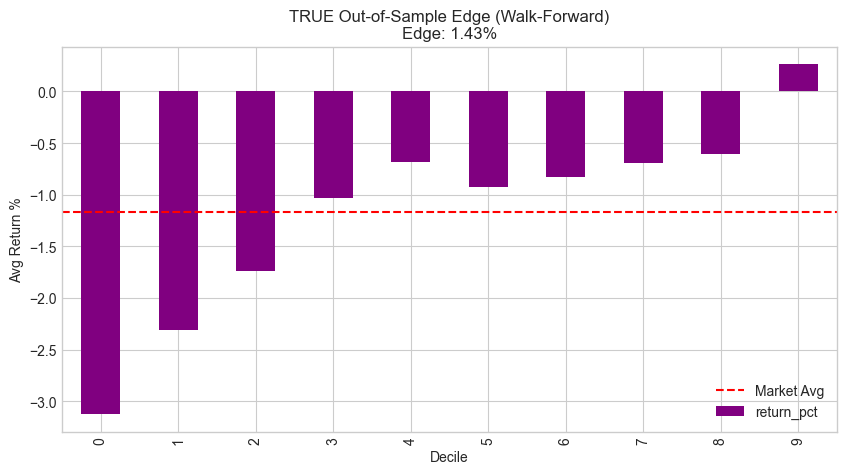

Honest Selection Edge: +1.43%


In [57]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit

# 1. SETUP
# Use the BEST parameters found by Optuna
best_params = {
    'n_estimators': 311,
    'max_depth': 3,
    'learning_rate': 0.014,
    'subsample': 0.87,
    'colsample_bytree': 0.71,
    'reg_alpha': 7.3,
    'reg_lambda': 2.8,
    'n_jobs': -1,
    'random_state': 42
}

X = df_mod[features]
y = df_mod[target]
dates = df_mod['date']

# 2. WALK-FORWARD PREDICTION (Stitching the OOS results)
# We will NOT train on all data. We will simulate "living through" the data.
tscv = TimeSeriesSplit(n_splits=5)

oos_predictions = []
oos_indices = []

print("Running Walk-Forward Backtest...")
for train_idx, test_idx in tscv.split(X):
    # Split
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Train
    model = xgb.XGBRegressor(**best_params)
    model.fit(X_train, y_train)
    
    # Predict (Only on the new, unseen data)
    preds = model.predict(X_test)
    
    # Store
    oos_predictions.extend(preds)
    oos_indices.extend(test_idx)

# 3. ANALYZE "HONEST" PERFORMANCE
# Create a dataframe of ONLY the out-of-sample period
df_oos = df_mod.iloc[oos_indices].copy()
df_oos['OOS_Prediction'] = oos_predictions

# Decile Analysis
df_oos['Decile'] = pd.qcut(df_oos['OOS_Prediction'], 10, labels=False)
honest_edge = df_oos.groupby('Decile')[target].mean()

# 4. PLOT
plt.figure(figsize=(10, 5))
honest_edge.plot(kind='bar', color='purple')
plt.title(f"TRUE Out-of-Sample Edge (Walk-Forward)\nEdge: {honest_edge.iloc[-1] - df_oos[target].mean():.2f}%")
plt.ylabel("Avg Return %")
plt.axhline(df_oos[target].mean(), color='red', linestyle='--', label='Market Avg')
plt.legend()
plt.show()

print(f"Honest Selection Edge: +{honest_edge.iloc[-1] - df_oos[target].mean():.2f}%")

## 5. SHAP Explainability

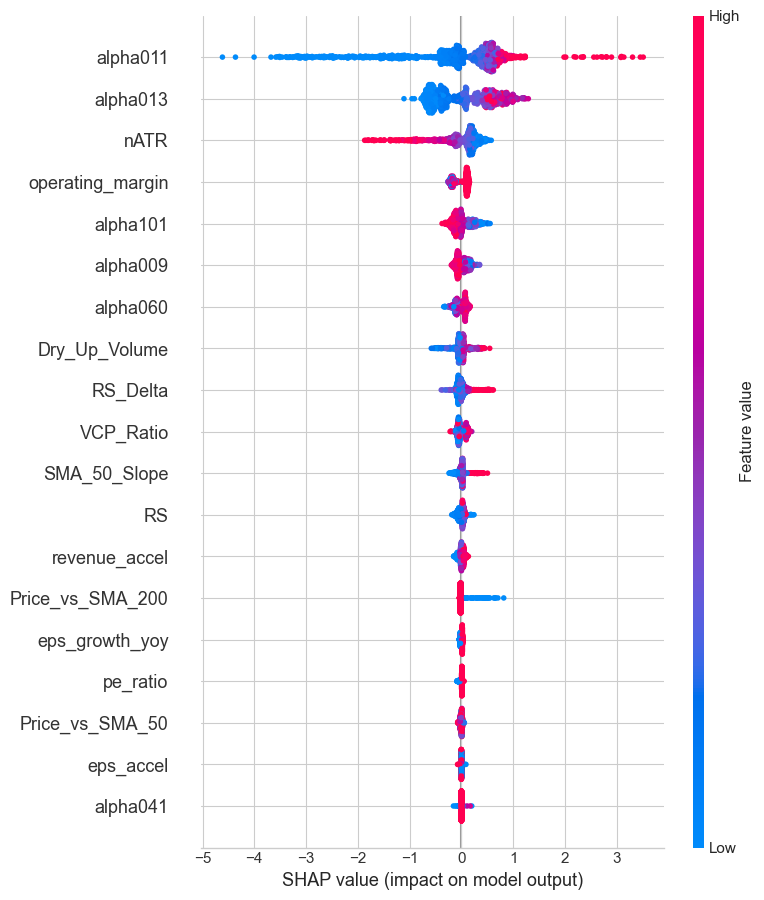

In [58]:
try:
    import shap
    
    # Create SHAP explainer
    explainer = shap.TreeExplainer(model)
    
    # Sample for speed
    sample_size = min(1000, len(X))
    X_sample = X.sample(sample_size, random_state=42)
    
    shap_values = explainer.shap_values(X_sample)
    
    # Summary plot
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_sample, max_display=20, show=False)
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("⚠️ SHAP not installed. Run: pip install shap")

## 6. Feature Selection Output

Based on the analysis above, select the final feature set for M01.

In [ ]:
# Select top N features (by importance, excluding highly correlated)
TOP_N = 40

# Get top features
selected_features = importance.head(TOP_N)['feature'].tolist()

# Remove highly correlated duplicates (keep one)
# This is a simple greedy approach
to_remove = set()
for _, row in high_corr_df.iterrows():
    f1, f2 = row['feature_1'], row['feature_2']
    if f1 in selected_features and f2 in selected_features:
        # Keep the one with higher importance
        imp1 = importance[importance['feature'] == f1]['importance'].values[0]
        imp2 = importance[importance['feature'] == f2]['importance'].values[0]
        to_remove.add(f2 if imp1 > imp2 else f1)

final_features = [f for f in selected_features if f not in to_remove]

print(f"Selected {len(final_features)} features (after removing {len(to_remove)} correlated):")
print(final_features)

In [ ]:
# Output as Python list (copy to feature_config.py)
print("\n# Copy this to src/feature_config.py M01_FEATURES:\n")
print("M01_FEATURES = [")
for f in final_features:
    print(f"    '{f}',")
print("]")

---
## Next Steps
1. Copy the `M01_FEATURES` list above to `src/feature_config.py`.
2. Re-run `model_trainer.py` to train with the optimized feature set.
3. Evaluate walk-forward metrics to confirm improvement.